In [207]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [209]:
df = pd.read_csv("New USA Life Expectancy.csv")
df.head()

,Year,LifeExp,Male Adult Mortality,Female Adult Mortality,Adult Mortality,Healthcare,GDP
0,1970,70.7343,236.992,128.466,365.458,1793.813,5234.296666
1,1971,71.0979,232.152,125.887,358.039,1877.729,5609.382600
2,1972,71.1779,232.026,124.305,356.331,2008.452,6094.017990
3,1973,71.3966,228.488,122.920,351.408,2106.882,6726.358956
4,1974,71.9592,219.819,117.149,336.968,2156.743,7225.691360


In [211]:
df.columns

Index(['Year', 'LifeExp', 'Male Adult Mortality', 'Female Adult Mortality ',
       'Adult Mortality', 'Healthcare', 'GDP'],
      dtype='object')

In [229]:
df['year_sq'] = df['Year'] ** 2                        # nonlinear trend
df['lag_1']   = df['LifeExp'].shift(1)                 # last year's value
df['lag_2']   = df['LifeExp'].shift(2)                 # 2 years ago
df['rolling3'] = df['LifeExp'].shift(1).rolling(3).mean()  # 3-year moving avg
df = df.dropna()

features = ['Year', 'lag_1', 'lag_2', 'rolling3', 'Adult Mortality', 'Healthcare', 'GDP']
X = df[features]
y = df['LifeExp']

# --- Chronological train/test split ---
split_year = 2015
X_train = X[df['Year'] <= split_year]
X_test  = X[df['Year'] >  split_year]
y_train = y[df['Year'] <= split_year]
y_test  = y[df['Year'] >  split_year]

# --- Train models ---
lr  = LinearRegression()
rf  = RandomForestRegressor(n_estimators=200, random_state=42)
xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

# --- Evaluate ---
for name, model in [('Linear Regression', lr), ('Random Forest', rf), ('XGBoost', xgb)]:
    preds = model.predict(X_test)
    rmse  = root_mean_squared_error(y_test, preds)
    r2    = r2_score(y_test, preds)
    print(f"{name:20s} | RMSE: {rmse:.3f} | R²: {r2:.3f}")

Linear Regression    | RMSE: 0.420 | R²: 0.807
Random Forest        | RMSE: 0.956 | R²: -0.002
XGBoost              | RMSE: 1.080 | R²: -0.280


In [265]:
# --- Build future rows one year at a time ---
# --- Project future feature values ---
# Use the last N years to estimate a trend for each feature
n = 5  # look at last 5 years of data to estimate trend

def project_feature(series, n_years, steps):
    """Fit a linear trend on the last n_years and project forward."""
    recent = series.iloc[-n_years:]
    x = np.arange(len(recent)).reshape(-1, 1)
    model = LinearRegression().fit(x, recent)
    future_x = np.arange(len(recent), len(recent) + steps).reshape(-1, 1)
    return model.predict(future_x)

future_years      = list(range(int(df['Year'].max()) + 1, int(df['Year'].max()) + 18))
future_healthcare = project_feature(df['Healthcare'], n, 17)
future_gdp        = project_feature(df['GDP'], n, 17)
future_mortality  = project_feature(df['Adult Mortality'], n, 17)

# --- Iterative forecast ---
history = df[['Year', 'LifeExp']].copy()
future_rows = []

for yr in range(last_year + 1, last_year + 18):  # next 17 years after 2023
    lag1     = history['LifeExp'].iloc[-1]
    lag2     = history['LifeExp'].iloc[-2]
    rolling3 = history['LifeExp'].iloc[-3:].mean()
    row = {
        'Year'          : yr,
        'Adult Mortality': future_mortality[i],
        'Healthcare'    : future_healthcare[i],
        'GDP'           : future_gdp[i],
        'lag_1'         : lag1,
        'lag_2'         : lag2,
        'rolling3'      : rolling3
    }
    future_rows.append(row)

future_df = pd.DataFrame(future_rows)
future_df['lr_pred']  = lr.predict(future_df[features])
future_df['rf_pred']  = rf.predict(future_df[features])
future_df['xgb_pred'] = xgb.predict(future_df[features])

print("\nForecast for Years 202:")
print(future_df[['Year', 'lr_pred', 'rf_pred', 'xgb_pred']].to_string(index=False))



Forecast for Years 202:
 Year   lr_pred   rf_pred  xgb_pred
 2024 77.132298 78.287636 78.721153
 2025 77.301920 78.287636 78.721153
 2026 77.471543 78.287636 78.721153
 2027 77.641166 78.287636 78.721153
 2028 77.810789 78.287636 78.721153
 2029 77.980412 78.287636 78.721153
 2030 78.150035 78.287636 78.721153
 2031 78.319658 78.287636 78.721153
 2032 78.489281 78.287636 78.721153
 2033 78.658903 78.287636 78.721153
 2034 78.828526 78.287636 78.721153
 2035 78.998149 78.287636 78.721153
 2036 79.167772 78.287636 78.721153
 2037 79.337395 78.287636 78.721153
 2038 79.507018 78.287636 78.721153
 2039 79.676641 78.287636 78.721153
 2040 79.846264 78.287636 78.721153


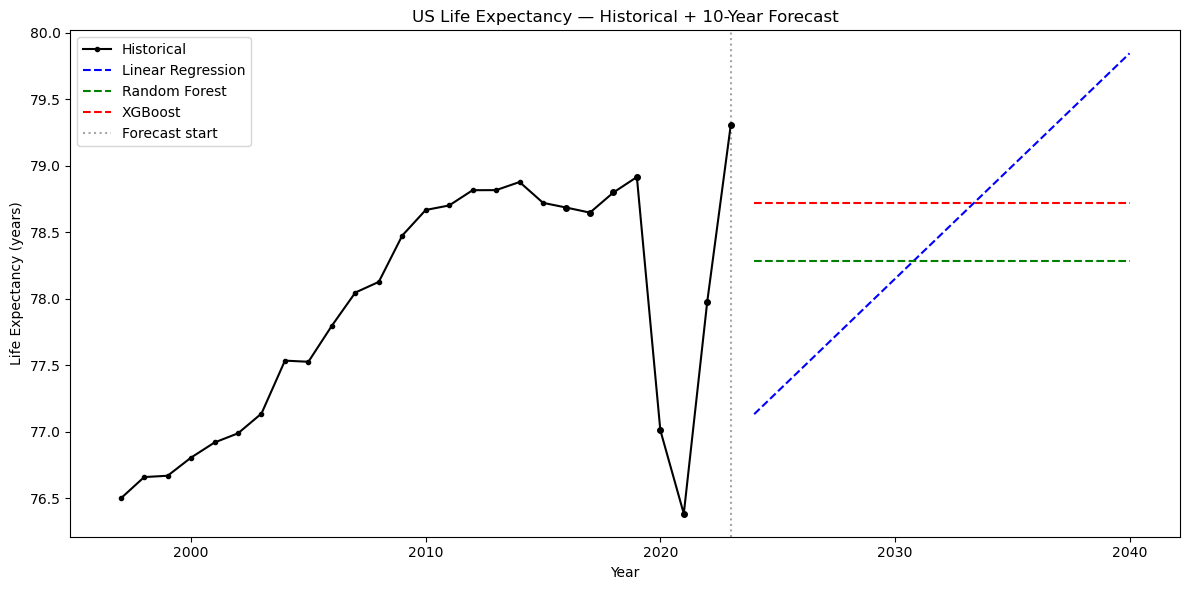

In [267]:
plt.figure(figsize=(12, 6))

# Historical data
plt.plot(df['Year'], df['LifeExp'], 'k-o', markersize=3, label='Historical', zorder=5)

# Test set actual
plt.plot(df[df['Year'] > split_year]['Year'], y_test, 'ko', markersize=4, zorder=5)

# Model forecasts
plt.plot(future_df['Year'], future_df['lr_pred'],  'b--', label='Linear Regression')
plt.plot(future_df['Year'], future_df['rf_pred'],  'g--', label='Random Forest')
plt.plot(future_df['Year'], future_df['xgb_pred'], 'r--', label='XGBoost')

# Divider line
plt.axvline(x=last_year, color='gray', linestyle=':', alpha=0.7, label='Forecast start')

plt.title('US Life Expectancy — Historical + 10-Year Forecast')
plt.xlabel('Year')
plt.ylabel('Life Expectancy (years)')
plt.legend()
plt.tight_layout()
plt.savefig('life_expectancy_forecast.png', dpi=150)
plt.show()